# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [40]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [42]:
# Завдання 1а — створіть масив і обчисліть статистику
arr = np.random.normal(0, 1, 10000)
print("середнє: ", np.mean(arr))
print("стандартне відхилення: ", np.std(arr))
print("мінімум: ", np.min(arr))
print("максимум: ", np.max(arr))

середнє:  0.009962575255699253
стандартне відхилення:  0.9923588543325217
мінімум:  -4.269215774561973
максимум:  3.921543349652825


In [43]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
avg = np.mean(arr)
std = np.std(arr)
emissions = arr[(arr < (avg - 2*std)) | (arr > (avg + 2*std))]

print("скільки значень виходять за межі: ", emissions.size)
print("відсоткова частка: ", emissions.size / arr.size * 100)

скільки значень виходять за межі:  448
відсоткова частка:  4.4799999999999995


Відсоткова частка є меншою ніж теоретичне значення

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [44]:
# Завантаження набору даних
sales = pd.read_csv('/home/kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [45]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print("рядків: ", rows)
print("стовпців: ", cols)

рядків:  21613
стовпців:  21


In [46]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
print("Мінімум: ", sales['price'].min())
print("максимум: ", sales['price'].max())
print("середнє: ", sales['price'].mean())
print("медіана ціни: ", sales['price'].median())

Мінімум:  75000.0
максимум:  7700000.0
середнє:  540088.1417665294
медіана ціни:  450000.0


In [47]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
print("Кількість унікальних поштових індексів: ", sales['zipcode'].nunique())
print("індекс з найбільшою кількістю оголошень: ", sales['zipcode'].value_counts().idxmax())

Кількість унікальних поштових індексів:  70
індекс з найбільшою кількістю оголошень:  98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

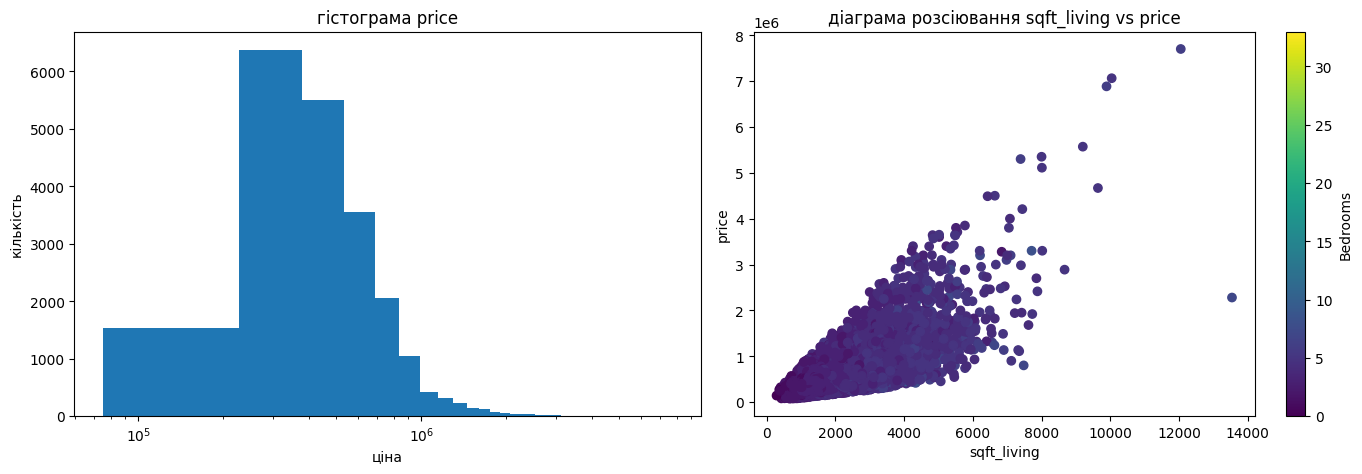

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales['price'], bins=50)
axes[0].set_xlabel('ціна')
axes[0].set_ylabel('кількість')
axes[0].set_xscale('log')
axes[0].set_title('гістограма price')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
graph = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'])
axes[1].set_xlabel('sqft_living')
axes[1].set_ylabel('price')
axes[1].set_title('діаграма розсіювання sqft_living vs price')
plt.colorbar(graph, ax=axes[1], label='Bedrooms')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Гістограма має лише 22 помітні стовпчики, що може бути пов'язано з використанням логаріфмічної шкали або наявністю пустих інтервалів.

**Спостереження (правий графік):**  Збільшення площини зазвичай призводить до зростання ціни.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [49]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [54]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
model = LinearRegression()
model.fit(train_data[['sqft_living']], train_data['price'])

print("intercept: ", model.intercept_)
print("коефіцієнт (вага): ", model.coef_[0])

predict = model.predict(test_data[['sqft_living']])
mse = mean_squared_error(test_data['price'], predict)
print("MSE: ", mse)
print("RMSE: ", np.sqrt(mse))

print("передбачувана ціна будинку площею 2 500 кв. футів: ", model.predict(pd.DataFrame({'sqft_living': [2500]}))[0])

intercept:  -41999.18603993731
коефіцієнт (вага):  279.55477931526383
MSE:  76484977061.77612
RMSE:  276559.1746114674
передбачувана ціна будинку площею 2 500 кв. футів:  656887.7622482223


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [51]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
model2 = LinearRegression()
model2.fit(train_data[['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']], train_data['price'])

predict2 = model2.predict(test_data[['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']])
mse2 = mean_squared_error(test_data['price'], predict2)

print("RMSE model 1: ", np.sqrt(mse))
print("RMSE model 2: ", np.sqrt(mse2))


RMSE model 1:  276559.1746114674
RMSE model 2:  262985.9758719034


**Відповідь:** RMSE другої моделі є нижчим ніж у першої на 13574, оскільки використання додаткових ознак дозволяє зменшити похибку прогнозу.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

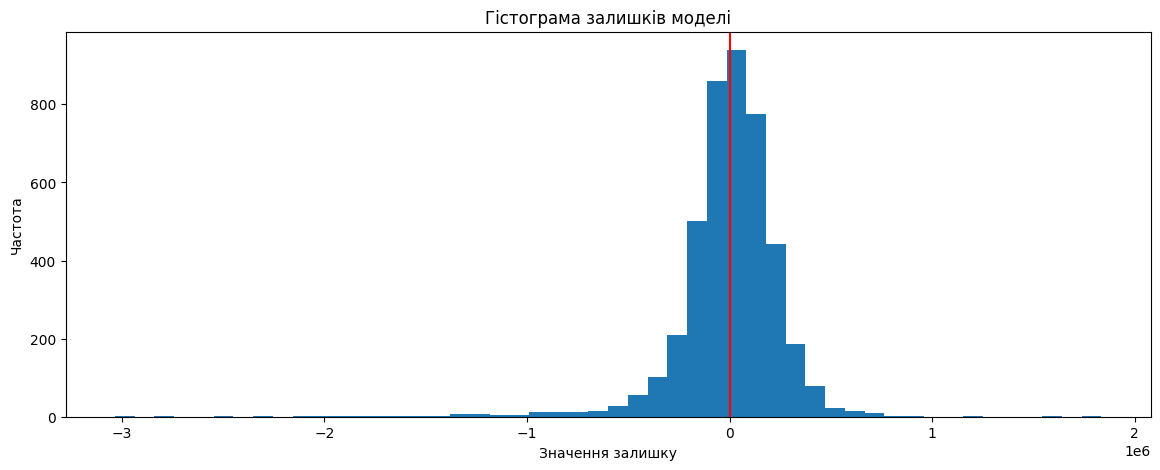

In [52]:
# Бонус — аналіз залишків
residuals_vec = predict2 - test_data['price']

plt.figure(figsize=(14, 5))
plt.hist(residuals_vec, bins=50)
plt.axvline(x=0, color='red')
plt.xlabel('Значення залишку')
plt.ylabel('Частота')

plt.title('Гістограма залишків моделі')
plt.show()

**Спостереження:** Залишки розподілені близько до нормального закону та центровані навколо нуля. Однак спостерігається від'ємна асиметрія, що вказує на недооцінювання дорогих об'єктів. Систематичний ненульовий середній залишок означав би наявність постійного зміщення (модель переоцінює або недооцінює об'єкти).